<a href="https://colab.research.google.com/github/Jaagrav-07/assignment-02--bitsom_ba_2511717/blob/main/part4-vector-db/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Install Library

!pip install sentence-transformers seaborn matplotlib

In [2]:
#Import Libraries

from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#Sentences (10 total, 3 topics)

sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler took five wickets",
    "The team won the cricket tournament",

    # Cooking
    "Add salt and spices while cooking the curry",
    "The chef prepared a delicious meal",
    "Baking requires precise measurements",

    # Cybersecurity
    "Cyber attacks can compromise sensitive data",
    "Encryption protects user information",
    "Firewalls help prevent unauthorized access",
    "Phishing attacks trick users into revealing passwords"
]

In [4]:
#Load Model + Generate Embeddings

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
#Cosine Similarity Matrix

similarity_matrix = np.inner(embeddings, embeddings)
similarity_matrix

array([[ 0.9999999 ,  0.5735829 ,  0.56121093,  0.07447296,  0.13094799,
         0.15403494,  0.10499255, -0.02194865, -0.0509324 ,  0.00533621],
       [ 0.5735829 ,  1.        ,  0.54858166,  0.18956628,  0.24097678,
         0.08689198,  0.14261061,  0.01984682, -0.10823698,  0.05476343],
       [ 0.56121093,  0.54858166,  0.9999999 ,  0.06019266,  0.14198914,
         0.02411336,  0.07198691,  0.03069218, -0.02009539,  0.00322976],
       [ 0.07447296,  0.18956628,  0.06019266,  1.0000001 ,  0.41153586,
         0.06131773,  0.05205841,  0.02314771,  0.05085322,  0.13545983],
       [ 0.13094799,  0.24097678,  0.14198914,  0.41153586,  0.9999999 ,
         0.28631276,  0.0223966 ,  0.02423474,  0.03014771,  0.05930328],
       [ 0.15403494,  0.08689198,  0.02411336,  0.06131773,  0.28631276,
         1.        ,  0.04297758,  0.04634336, -0.01572849,  0.08716269],
       [ 0.10499255,  0.14261061,  0.07198691,  0.05205841,  0.0223966 ,
         0.04297758,  0.99999994,  0.47733134

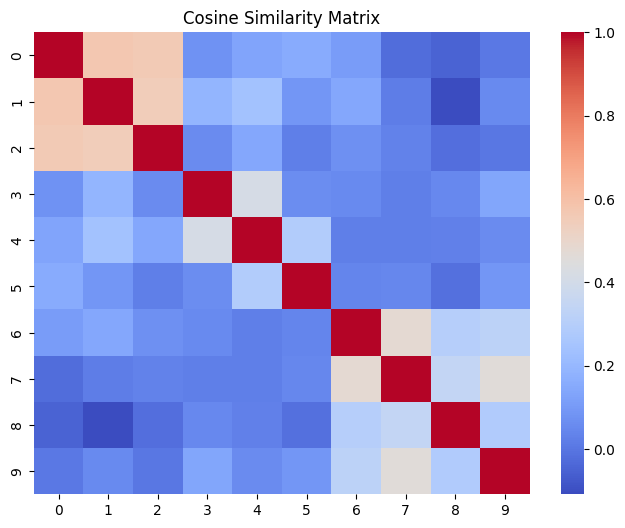

In [6]:
#Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=False, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [7]:
#Query Similarity

query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = np.inner(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")
    print()

Sentence: The bowler took five wickets
Similarity Score: 0.8452

Sentence: The batsman scored a century in the match
Similarity Score: 0.5682

